# 02 — Сравнение методов VaR и честный бэктест

Портфель: равные веса SPY / QQQ / TLT / GLD, 2015–2025.
Считаем 99% VaR тремя методами, затем прогоняем rolling out-of-sample бэктест
(окно 250 дней) и проверяем каждую модель тестами Купика и Кристофферсена.

In [1]:
import numpy as np
import pandas as pd

from riskforge.backtest import christoffersen_test, kupiec_test, rolling_var_backtest
from riskforge.data import load_prices, log_returns
from riskforge.plotting import plot_returns_with_var
from riskforge.portfolio import portfolio_returns
from riskforge.var import historical_var, monte_carlo_var, parametric_var

TICKERS = ["SPY", "QQQ", "TLT", "GLD"]
ALPHA = 0.99

prices = load_prices(TICKERS, start="2015-01-01", end="2025-06-01")
asset_returns = log_returns(prices)
weights = np.full(len(TICKERS), 0.25)
port = portfolio_returns(asset_returns, weights)
print(f"{len(port)} дней, vol портфеля {port.std() * np.sqrt(252):.1%} годовых")

2617 дней, vol портфеля 11.2% годовых


## Статический VaR по всей выборке

In [2]:
static = pd.Series(
    {
        "Historical": historical_var(port, ALPHA),
        "Normal": parametric_var(port, ALPHA, dist="normal"),
        "Student-t": parametric_var(port, ALPHA, dist="t"),
        "Monte Carlo (Normal, 100k)": monte_carlo_var(
            asset_returns, weights, alpha=ALPHA, n_sims=100_000, seed=42
        ),
    },
    name="VaR 99%",
)
print((static * 100).round(3).astype(str) + " %")

Historical                    1.873 %
Normal                        1.611 %
Student-t                     1.855 %
Monte Carlo (Normal, 100k)    1.606 %
Name: VaR 99%, dtype: str


Ожидаемая картина: MC ≈ Normal (одно и то же гауссово предположение,
разница — ошибка симуляции), а Historical и Student-t выше — они видят
жирные хвосты. Но статический VaR по всей выборке — это in-sample оценка;
единственная честная проверка — out-of-sample бэктест.

## Rolling-бэктест (окно 250 дней, без look-ahead)

In [3]:
estimators = {
    "Historical": lambda w: historical_var(w, ALPHA),
    "Normal": lambda w: parametric_var(w, ALPHA, dist="normal"),
    "Student-t": lambda w: parametric_var(w, ALPHA, dist="t"),
}
backtests = {name: rolling_var_backtest(port, fn, window=250) for name, fn in estimators.items()}

rows = []
for name, bt in backtests.items():
    kup = kupiec_test(bt["breach"], alpha=ALPHA)
    chr_ = christoffersen_test(bt["breach"])
    rows.append(
        {
            "модель": name,
            "дней": kup.n_obs,
            "пробитий": kup.n_breaches,
            "ожидалось": round(kup.expected_breaches, 1),
            "Kupiec p-value": round(kup.p_value, 4),
            "Kupiec вердикт": "REJECT" if kup.reject_h0 else "pass",
            "Christoffersen p-value": round(chr_.p_value, 4),
            "Christ. вердикт": "REJECT" if chr_.reject_h0 else "pass",
        }
    )
results = pd.DataFrame(rows).set_index("модель")
print(results.to_string())

            дней  пробитий  ожидалось  Kupiec p-value Kupiec вердикт  Christoffersen p-value Christ. вердикт
модель                                                                                                      
Historical  2367        32       23.7          0.1024           pass                  0.0007          REJECT
Normal      2367        58       23.7          0.0000         REJECT                  0.0153          REJECT
Student-t   2367        38       23.7          0.0065         REJECT                  0.0029          REJECT


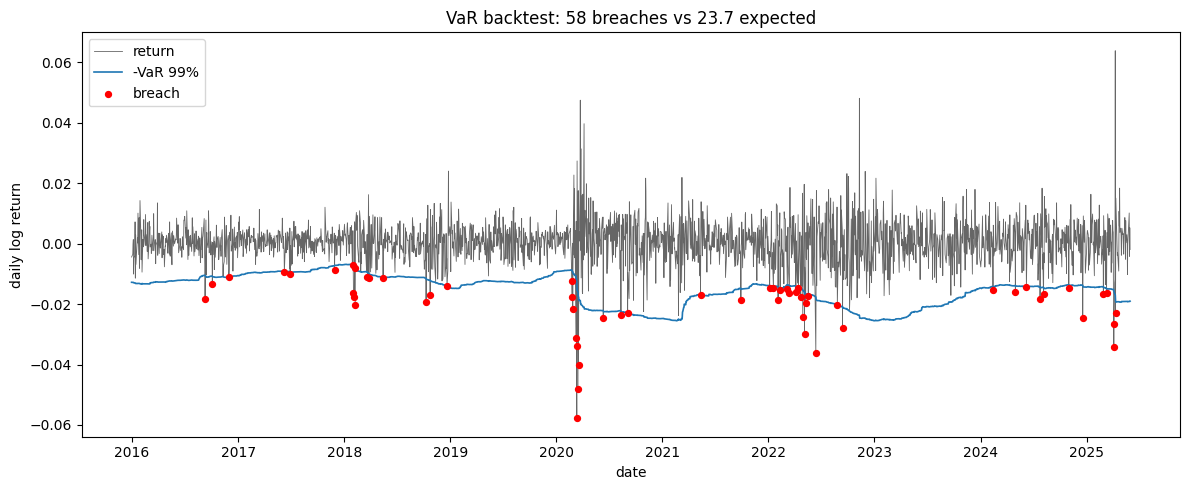

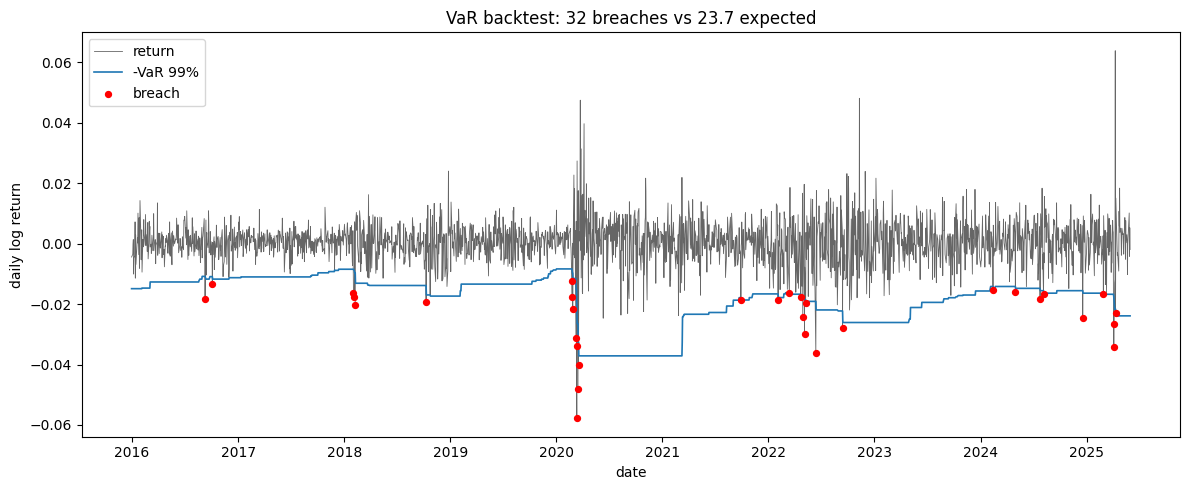

In [4]:
fig = plot_returns_with_var(backtests["Normal"], alpha=ALPHA)
fig = plot_returns_with_var(backtests["Historical"], alpha=ALPHA)

## Как читать результаты

* **Kupiec REJECT с избытком пробитий** — модель систематически занижает риск.
  Типично для Normal: тонкие хвосты + резкие смены режима (COVID-2020).
* **Christoffersen REJECT** — пробития кластеризуются: модель с окном 250 дней
  медленно догоняет новый режим волатильности, серия пробитий идёт подряд
  (видно на графиках в марте 2020). Это аргумент за условную волатильность —
  EWMA/GARCH-VaR (ноутбук 03), а не за другой безусловный метод.
* Student-t обычно проходит Купика лучше Normal (хвосты толще ⇒ VaR выше ⇒
  пробитий меньше), но кластеризацию лечит не он, а динамическая σ_t.

Точные числа зависят от периода — выводы выше сверяй с таблицей, а не наоборот.